In [1]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
from pathlib import Path
from cartopy.io import shapereader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rich import print
import shutil

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
own_region = "Rhine"

path = Path.cwd()
forcing_path = path / "Rhine"
shapeFile = forcing_path / f"{own_region}.shp"

savelocation = forcing_path / f"{own_region}Forcing"

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

import ewatercycle
from ewatercycle.models import Wflow
from ewatercycle.parameter_sets import available_parameter_sets

In [4]:
parameter_sets = available_parameter_sets(target_model="wflow")

print(parameter_sets.keys())

dict_keys(['wflow_rhine_sbm_nc', 'wflow_Rhine_ERA5-calibrated', 'wflow_Great-Kei_ERA5-calibrated', 
'wflow_Doring_ERA5-calibrated', 'wflow_Merrimack_ERA5-calibrated', 'wflow_Meuse_ERA5-calibrated', 
'wflow_rhine_ERA_Interim-calibrated', 'wflow_Savannah_ERA-Interim-calibrated', 
'wflow_Great-Kei_ERA_Interim-calibrated', 'wflow_Merrimack_ERA_Interim-calibrated', 
'wflow_Meuse_ERA_Interim-calibrated', 'wflow_merrimack_techpaper'])

In [5]:
parameter_set = parameter_sets["wflow_rhine_sbm_nc"]

print(parameter_set)
print(parameter_set.directory)
print(parameter_set.config)

ParameterSet(
    name='wflow_rhine_sbm_nc',
    directory=PosixPath('/data/shared/parameter-sets/wflow_rhine_sbm_nc'),
    config=PosixPath('/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini'),
    doi='N/A',
    target_model='wflow',
    supported_model_versions={'2020.1.3', '2020.1.1', '2020.1.2'},
    downloader=None
)

/data/shared/parameter-sets/wflow_rhine_sbm_nc

/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini

In [6]:
parameter_set.config = Path(parameter_set.directory) / "wflow_sbm_NC.ini"

print(parameter_set.config)
print(parameter_set.config.exists())

/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini

True

In [7]:
model = Wflow(parameter_set=parameter_set)

print(model)

Wflow(
    parameter_set=ParameterSet(
        name='wflow_rhine_sbm_nc',
        directory=PosixPath('/data/shared/parameter-sets/wflow_rhine_sbm_nc'),
        config=PosixPath('/data/shared/parameter-sets/wflow_rhine_sbm_nc/wflow_sbm_NC.ini'),
        doi='N/A',
        target_model='wflow',
        supported_model_versions={'2020.1.3', '2020.1.1', '2020.1.2'},
        downloader=None
    ),
    forcing=None
)

In [8]:
config_file, config_dir = model.setup()

print(config_file)
print(config_dir)

/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_124812/wflow_ewatercycle.ini

/home/niels/BEP-Niels/Troepnotebooks/wflow_20260513_124812

In [9]:
model.initialize(config_file)

In [10]:
print("Start time:", model.start_time)
print("End time:", model.end_time)
print("Current time:", model.time)

Start time: 665366400.0

End time: 667785600.0

Current time: 665280000.0

In [11]:
staticmaps_file = Path(parameter_set.directory) / "staticmaps.nc"

ds = xr.open_dataset(staticmaps_file)

print(ds)

<xarray.Dataset> Size: 3MB
Dimensions:                     (time: 1, lat: 169, lon: 187)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2014-05-25
  * lat                         (lat) float32 676B 52.05 52.02 ... 45.93 45.89
  * lon                         (lon) float32 748B 5.227 5.264 ... 12.01 12.05
Data variables: (12/23)
    crs                         |S1 1B ...
    wflow_bankfulldepth.map     (time, lat, lon) float32 126kB ...
    wflow_catchment.map         (time, lat, lon) float32 126kB ...
    wflow_dem.map               (time, lat, lon) float32 126kB ...
    wflow_dem10.map             (time, lat, lon) float32 126kB ...
    wflow_dem25.map             (time, lat, lon) float32 126kB ...
    ...                          ...
    wflow_riverburnin.map       (time, lat, lon) float32 126kB ...
    wflow_riverdem.map          (time, lat, lon) float32 126kB ...
    wflow_riverlength_fact.map  (time, lat, lon) float32 126kB ...
    wflow_soil.map              (time, lat, lon) float32 126kB ...
    wflow_streamorder.map       (time, lat, lon) float32 126kB ...
    wflow_subcatch.map          (time, lat, lon) float32 126kB ...
Attributes:
    title:        wflow input mapstack
    Conventions:  CF-1.4
    source:       pcr2netcdf
    references:   http://wflow.googlecode.com
    institution:  Deltares
    history:      Thu Nov 12 19:25:55 2015

In [12]:
for var in ds.data_vars:
    print(var)

crs

wflow_bankfulldepth.map

wflow_catchment.map

wflow_dem.map

wflow_dem10.map

...

wflow_riverdem.map

wflow_riverlength_fact.map

wflow_soil.map

wflow_streamorder.map

wflow_subcatch.map

In [13]:
lat_lobith = 51.86
lon_lobith = 6.12

In [14]:
nearest = ds.sel(lat=lat_lobith, lon=lon_lobith, method="nearest")

lat_model = float(nearest.lat.values)
lon_model = float(nearest.lon.values)

print("Dichtstbijzijnde modelcel:")
print("lat:", lat_model)
print("lon:", lon_model)

Dichtstbijzijnde modelcel:

lat: 51.870933532714844

lon: 6.107163429260254

In [15]:
lat_index = np.where(ds.lat.values == lat_model)[0][0]
lon_index = np.where(ds.lon.values == lon_model)[0][0]

nlon = len(ds.lon)
index_lobith = lat_index * nlon + lon_index

print("lat_index:", lat_index)
print("lon_index:", lon_index)
print("index_lobith:", index_lobith)

lat_index: 5

lon_index: 24

index_lobith: 959

In [16]:
print("catchment:", ds["wflow_catchment.map"].isel(time=0, lat=lat_index, lon=lon_index).values)
print("river:", ds["wflow_river.map"].isel(time=0, lat=lat_index, lon=lon_index).values)
print("streamorder:", ds["wflow_streamorder.map"].isel(time=0, lat=lat_index, lon=lon_index).values)
print("subcatch:", ds["wflow_subcatch.map"].isel(time=0, lat=lat_index, lon=lon_index).values)

catchment: 1.0

river: nan

streamorder: 1.0

subcatch: 6.0

In [17]:
Q_lobith = []
time = []

while model.time < model.end_time:
    model.update()
    
    river_runoff = model.get_value("RiverRunoff")
    value_lobith = river_runoff[index_lobith]
    
    Q_lobith.append(value_lobith)
    time.append(pd.to_datetime(model.time, unit="s"))

In [18]:
df = pd.DataFrame(
    data=Q_lobith,
    columns=["RiverRunoff near Lobith"],
    index=time
)

df.head()

,RiverRunoff near Lobith
1991-02-01,0.0
1991-02-02,0.0
1991-02-03,0.0
1991-02-04,0.0
1991-02-05,0.0


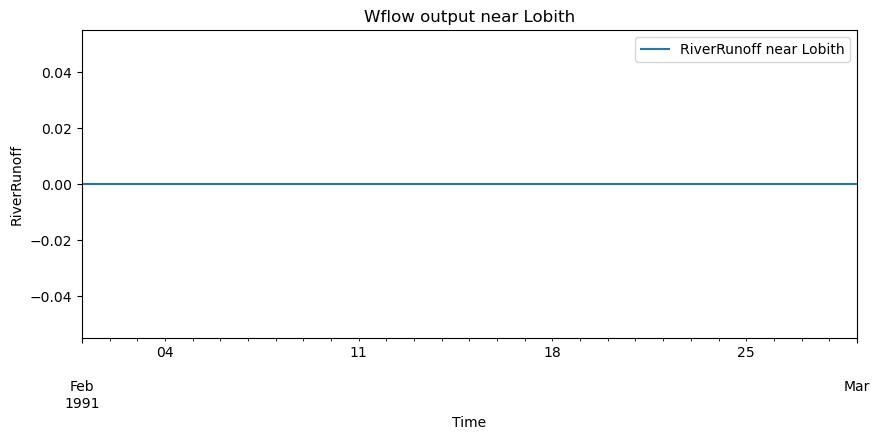

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

df.plot(ax=ax)

ax.set_ylabel("RiverRunoff")
ax.set_xlabel("Time")
ax.set_title("Wflow output near Lobith")
plt.show()

In [24]:
import numpy as np

lat_lobith = 51.86
lon_lobith = 6.12

river = ds["wflow_river.map"].isel(time=0)

# Cellen waar wflow_river.map niet NaN is, behandelen we als riviercellen
river_mask = ~np.isnan(river.values)

lat_values = ds.lat.values
lon_values = ds.lon.values

# Maak 2D arrays met lat/lon voor elke gridcel
lon_grid, lat_grid = np.meshgrid(lon_values, lat_values)

# Afstand tot Lobith berekenen
distance = np.sqrt((lat_grid - lat_lobith)**2 + (lon_grid - lon_lobith)**2)

# Niet-riviercellen uitsluiten
distance[~river_mask] = np.inf

# Dichtstbijzijnde riviercel zoeken
lat_index_river, lon_index_river = np.unravel_index(
    np.argmin(distance),
    distance.shape
)

print("Dichtstbijzijnde riviercel bij Lobith:")
print("lat_index_river:", lat_index_river)
print("lon_index_river:", lon_index_river)
print("lat:", ds.lat.values[lat_index_river])
print("lon:", ds.lon.values[lon_index_river])
print("afstand:", distance[lat_index_river, lon_index_river])

Dichtstbijzijnde riviercel bij Lobith:

lat_index_river: 6

lon_index_river: 24

lat: 51.834267

lon: 6.1071634

afstand: 0.028757794

In [25]:
for i in range(30):
    model.update()
    river_runoff = model.get_value("RiverRunoff")
    
    print(
        i,
        pd.to_datetime(model.time, unit="s"),
        "max:",
        np.nanmax(river_runoff),
        "non-zero:",
        np.count_nonzero(river_runoff)
    )

0 1991-04-01 00:00:00 max: 510.4358 non-zero: 1454

1 1991-04-02 00:00:00 max: 495.92218 non-zero: 1454

2 1991-04-03 00:00:00 max: 482.2949 non-zero: 1454

3 1991-04-04 00:00:00 max: 471.45352 non-zero: 1454

4 1991-04-05 00:00:00 max: 459.00647 non-zero: 1454

...

25 1991-04-26 00:00:00 max: 1131.4495 non-zero: 1454

26 1991-04-27 00:00:00 max: 1127.7185 non-zero: 1454

27 1991-04-28 00:00:00 max: 1121.8611 non-zero: 1454

28 1991-04-29 00:00:00 max: 1110.8058 non-zero: 1454

29 1991-04-30 00:00:00 max: 1100.7877 non-zero: 1454

In [28]:
river_runoff = model.get_value("RiverRunoff")

nlat = len(ds.lat)
nlon = len(ds.lon)

print("length output:", len(river_runoff))
print("nlat * nlon:", nlat * nlon)

length output: 31603

nlat * nlon: 31603

In [30]:
print("catchment:", ds["wflow_catchment.map"].isel(time=0, lat=lat_index_river, lon=lon_index_river).values)
print("river:", ds["wflow_river.map"].isel(time=0, lat=lat_index_river, lon=lon_index_river).values)
print("streamorder:", ds["wflow_streamorder.map"].isel(time=0, lat=lat_index_river, lon=lon_index_river).values)
print("subcatch:", ds["wflow_subcatch.map"].isel(time=0, lat=lat_index_river, lon=lon_index_river).values)

catchment: 1.0

river: 9.0

streamorder: 1.0

subcatch: 6.0

In [31]:
river_runoff = model.get_value("RiverRunoff")

nlat = len(ds.lat)
nlon = len(ds.lon)

runoff_grid_1 = river_runoff.reshape((nlat, nlon))
runoff_grid_2 = river_runoff.reshape((nlon, nlat)).T

print("Methode 1 bij Lobith-riviercel:", runoff_grid_1[lat_index_river, lon_index_river])
print("Methode 2 bij Lobith-riviercel:", runoff_grid_2[lat_index_river, lon_index_river])

print("Max methode 1:", np.nanmax(runoff_grid_1))
print("Max methode 2:", np.nanmax(runoff_grid_2))

Methode 1 bij Lobith-riviercel: 0.0

Methode 2 bij Lobith-riviercel: 0.0

Max methode 1: 1100.7877

Max methode 2: 1100.7877

In [32]:
runoff_grid = river_runoff.reshape((nlat, nlon))

max_index = np.unravel_index(np.nanargmax(runoff_grid), runoff_grid.shape)

print("Max waarde:", runoff_grid[max_index])
print("lat_index:", max_index[0])
print("lon_index:", max_index[1])
print("lat:", ds.lat.values[max_index[0]])
print("lon:", ds.lon.values[max_index[1]])

print("catchment:", ds["wflow_catchment.map"].isel(time=0, lat=max_index[0], lon=max_index[1]).values)
print("river:", ds["wflow_river.map"].isel(time=0, lat=max_index[0], lon=max_index[1]).values)
print("streamorder:", ds["wflow_streamorder.map"].isel(time=0, lat=max_index[0], lon=max_index[1]).values)
print("subcatch:", ds["wflow_subcatch.map"].isel(time=0, lat=max_index[0], lon=max_index[1]).values)

Max waarde: 1100.7877

lat_index: 164

lon_index: 11

lat: 46.04093

lon: 5.6304965

catchment: 0.0

river: nan

streamorder: 1.0

subcatch: nan

In [33]:
lat_lobith = 51.86
lon_lobith = 6.12

# Alleen cellen gebruiken waar RiverRunoff groter is dan 0
runoff_mask = runoff_grid > 0

lon_grid, lat_grid = np.meshgrid(ds.lon.values, ds.lat.values)

distance = np.sqrt((lat_grid - lat_lobith)**2 + (lon_grid - lon_lobith)**2)

# Cellen zonder afvoer uitsluiten
distance[~runoff_mask] = np.inf

lat_index_q, lon_index_q = np.unravel_index(
    np.argmin(distance),
    distance.shape
)

print("Dichtstbijzijnde cel met RiverRunoff > 0:")
print("lat_index:", lat_index_q)
print("lon_index:", lon_index_q)
print("lat:", ds.lat.values[lat_index_q])
print("lon:", ds.lon.values[lon_index_q])
print("afstand:", distance[lat_index_q, lon_index_q])
print("RiverRunoff:", runoff_grid[lat_index_q, lon_index_q])

print("catchment:", ds["wflow_catchment.map"].isel(time=0, lat=lat_index_q, lon=lon_index_q).values)
print("river:", ds["wflow_river.map"].isel(time=0, lat=lat_index_q, lon=lon_index_q).values)
print("streamorder:", ds["wflow_streamorder.map"].isel(time=0, lat=lat_index_q, lon=lon_index_q).values)
print("subcatch:", ds["wflow_subcatch.map"].isel(time=0, lat=lat_index_q, lon=lon_index_q).values)

Dichtstbijzijnde cel met RiverRunoff > 0:

lat_index: 28

lon_index: 47

lat: 51.0276

lon: 6.9504967

...

RiverRunoff: 2.0854256

catchment: 1.0

river: 9.0

streamorder: 1.0

subcatch: 6.0

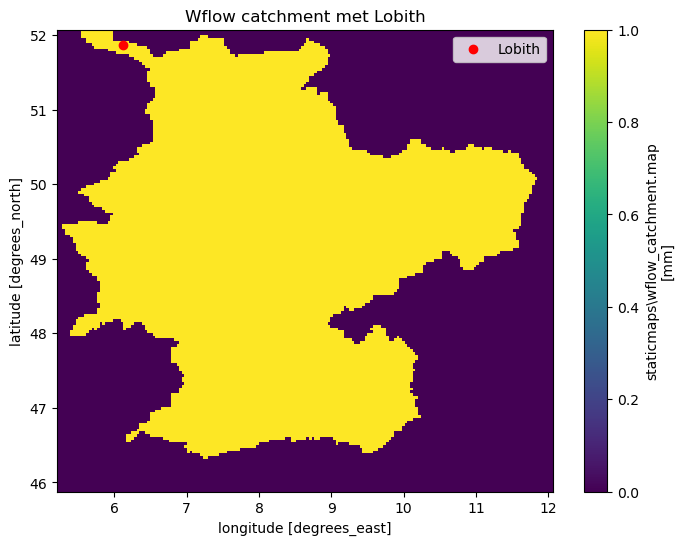

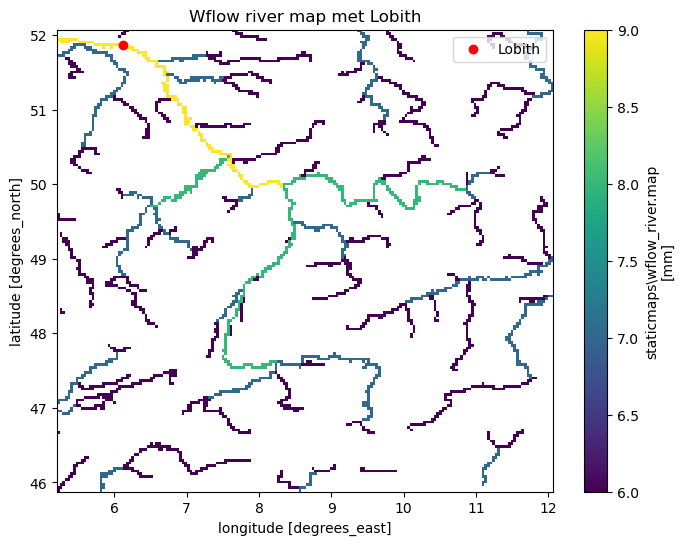

In [34]:
import numpy as np
import matplotlib.pyplot as plt

river = ds["wflow_river.map"].isel(time=0)
catchment = ds["wflow_catchment.map"].isel(time=0)

plt.figure(figsize=(8, 6))
catchment.plot()
plt.scatter(6.12, 51.86, color="red", label="Lobith")
plt.legend()
plt.title("Wflow catchment met Lobith")
plt.show()

plt.figure(figsize=(8, 6))
river.plot()
plt.scatter(6.12, 51.86, color="red", label="Lobith")
plt.legend()
plt.title("Wflow river map met Lobith")
plt.show()

In [35]:
lat_lobith = 51.86
lon_lobith = 6.12

river = ds["wflow_river.map"].isel(time=0)
river_mask = ~np.isnan(river.values)

lon_grid, lat_grid = np.meshgrid(ds.lon.values, ds.lat.values)

distance = np.sqrt((lat_grid - lat_lobith)**2 + (lon_grid - lon_lobith)**2)
distance[~river_mask] = np.inf

flat_indices = np.argsort(distance.ravel())

count = 0

for flat_index in flat_indices:
    lat_i, lon_i = np.unravel_index(flat_index, distance.shape)
    
    if np.isinf(distance[lat_i, lon_i]):
        continue
    
    print("Riviercel", count + 1)
    print("lat:", ds.lat.values[lat_i])
    print("lon:", ds.lon.values[lon_i])
    print("afstand:", distance[lat_i, lon_i])
    print("river:", ds["wflow_river.map"].isel(time=0, lat=lat_i, lon=lon_i).values)
    print("streamorder:", ds["wflow_streamorder.map"].isel(time=0, lat=lat_i, lon=lon_i).values)
    print("subcatch:", ds["wflow_subcatch.map"].isel(time=0, lat=lat_i, lon=lon_i).values)
    print()
    
    count += 1
    if count == 10:
        break

Riviercel 1

lat: 51.834267

lon: 6.1071634

afstand: 0.028757794

river: 9.0

...

lon: 6.25383

afstand: 0.14766295

river: 9.0

streamorder: 1.0

subcatch: 6.0

In [36]:
river_runoff = model.get_value("RiverRunoff")

nlat = len(ds.lat)
nlon = len(ds.lon)

grid_base = river_runoff.reshape((nlat, nlon))

grids = {
    "base": grid_base,
    "flip_lat": grid_base[::-1, :],
    "flip_lon": grid_base[:, ::-1],
    "flip_lat_lon": grid_base[::-1, ::-1],
}

for name, grid in grids.items():
    max_index = np.unravel_index(np.nanargmax(grid), grid.shape)
    
    lat_i = max_index[0]
    lon_i = max_index[1]
    
    print("\n---", name, "---")
    print("max waarde:", grid[lat_i, lon_i])
    print("lat:", ds.lat.values[lat_i])
    print("lon:", ds.lon.values[lon_i])
    print("catchment:", ds["wflow_catchment.map"].isel(time=0, lat=lat_i, lon=lon_i).values)
    print("river:", ds["wflow_river.map"].isel(time=0, lat=lat_i, lon=lon_i).values)
    print("streamorder:", ds["wflow_streamorder.map"].isel(time=0, lat=lat_i, lon=lon_i).values)
    print("subcatch:", ds["wflow_subcatch.map"].isel(time=0, lat=lat_i, lon=lon_i).values)

--- base ---

max waarde: 1100.7877

lat: 46.04093

lon: 5.6304965

catchment: 0.0

...

lon: 11.64383

catchment: 0.0

river: nan

streamorder: 4.0

subcatch: nan

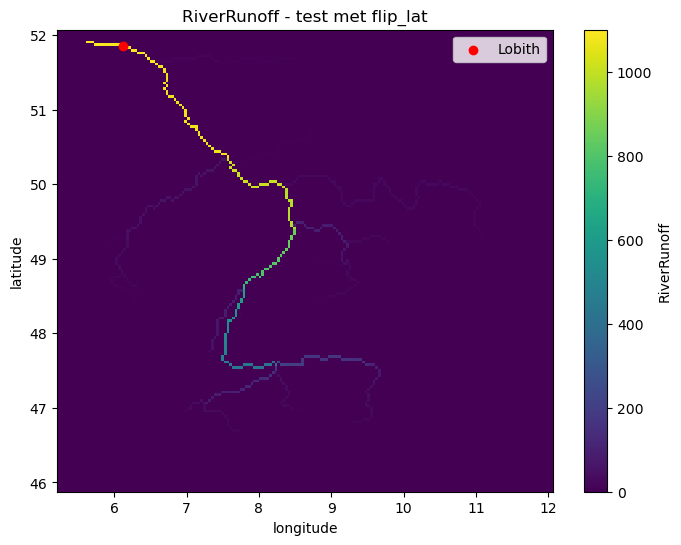

In [37]:
plt.figure(figsize=(8, 6))
plt.pcolormesh(ds.lon.values, ds.lat.values, grid_base[::-1, :])
plt.colorbar(label="RiverRunoff")
plt.scatter(6.12, 51.86, color="red", label="Lobith")
plt.legend()
plt.title("RiverRunoff - test met flip_lat")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

In [38]:
lat_lobith = 51.86
lon_lobith = 6.12

lon_grid, lat_grid = np.meshgrid(ds.lon.values, ds.lat.values)

distance = np.sqrt((lat_grid - lat_lobith)**2 + (lon_grid - lon_lobith)**2)

# Alleen cellen gebruiken met afvoer
mask = runoff_grid > 0

distance[~mask] = np.inf

lat_index_lobith, lon_index_lobith = np.unravel_index(
    np.argmin(distance),
    distance.shape
)

print("Gekozen cel nabij Lobith:")
print("lat_index:", lat_index_lobith)
print("lon_index:", lon_index_lobith)
print("lat:", ds.lat.values[lat_index_lobith])
print("lon:", ds.lon.values[lon_index_lobith])
print("afstand:", distance[lat_index_lobith, lon_index_lobith])
print("RiverRunoff:", runoff_grid[lat_index_lobith, lon_index_lobith])

Gekozen cel nabij Lobith:

lat_index: 28

lon_index: 47

lat: 51.0276

lon: 6.9504967

afstand: 1.1758473

RiverRunoff: 2.0854256

In [39]:
Q_lobith_like = []
time = []

for i in range(100):
    model.update()
    
    river_runoff = model.get_value("RiverRunoff")
    runoff_grid = river_runoff.reshape((nlat, nlon))[::-1, :]
    
    value = runoff_grid[lat_index_lobith, lon_index_lobith]
    
    Q_lobith_like.append(value)
    time.append(pd.to_datetime(model.time, unit="s"))

In [40]:
df = pd.DataFrame(
    data=Q_lobith_like,
    index=time,
    columns=["RiverRunoff near Lobith"]
)

df.head()

,RiverRunoff near Lobith
1991-05-01,1067.378784
1991-05-02,1047.398926
1991-05-03,1009.313904
1991-05-04,955.178284
1991-05-05,889.817871


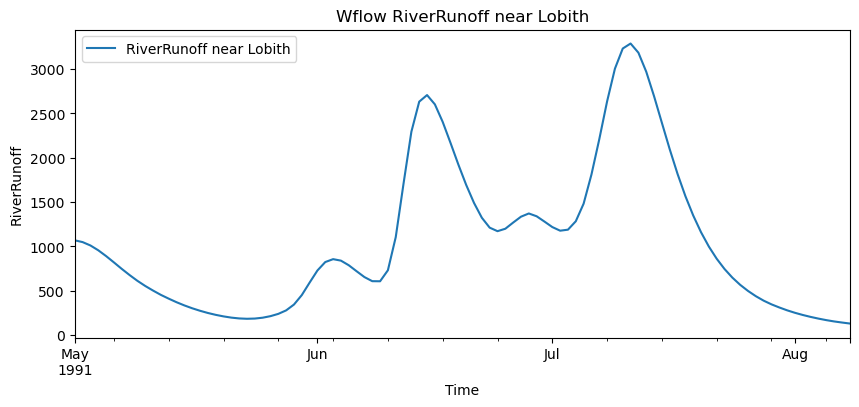

In [41]:
df.plot(figsize=(10, 4))
plt.ylabel("RiverRunoff")
plt.xlabel("Time")
plt.title("Wflow RiverRunoff near Lobith")
plt.show()

In [42]:
import pandas as pd

start_date = pd.to_datetime(model.start_time, unit="s")
end_date = pd.to_datetime(model.end_time, unit="s")
current_date = pd.to_datetime(model.time, unit="s")

print("Start:", start_date)
print("Current:", current_date)
print("End:", end_date)

Start: 1991-02-01 00:00:00

Current: 1991-08-08 00:00:00

End: 1991-03-01 00:00:00

In [43]:
print("Start:", start_date)
print("End:", end_date)

Start: 1991-02-01 00:00:00

End: 1991-03-01 00:00:00